In [1]:
# ================================
# 📌 Cell 1: Imports & Setup
# ================================
import os, random, joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, fbeta_score)
import matplotlib.pyplot as plt
import csv

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("="*50)
print(f"✅ Device in use: {device}")
print("="*50)

✅ Device in use: cuda


In [2]:
# ================================
# 📌 Cell 2: Load Data
# ================================
train_file = r"C:\Users\User\Desktop\Graduation Project\train_forecast24_patientaware.csv"
val_file   = r"C:\Users\User\Desktop\Graduation Project\val_forecast24_balanced20.csv"
test_file  = r"C:\Users\User\Desktop\Graduation Project\test_forecast24_balanced20.csv"

df_train = pd.read_csv(train_file)
df_val   = pd.read_csv(val_file)
df_test  = pd.read_csv(test_file)

print("📊 Data loaded successfully!")
print("Train shape:", df_train.shape)
print("Val shape:  ", df_val.shape)
print("Test shape: ", df_test.shape)
print("Columns in the dataset:", list(df_train.columns))

📊 Data loaded successfully!
Train shape: (146834, 18)
Val shape:   (51082, 18)
Test shape:  (53029, 18)
Columns in the dataset: ['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight', 'y_forecast_24h']


In [3]:
# ================================
# 📌 Cell 3: Config & Column Detection
# ================================
target_col = 'y_forecast_24h'

def detect_patient_id_col(df_list):
    prefs = ['patient_label', 'patient_id', 'new_id', 'pid', 'id', 'subject_id', 'sub']
    for p in prefs:
        for orig in df_list[0].columns:
            if orig.lower() == p:
                return orig
    for orig in df_list[0].columns:
        low = orig.lower()
        if 'patient' in low or low.endswith('_id') or low == 'id' or low == 'new_id' or low == 'sub':
            return orig
    for orig in df_list[0].columns:
        if 'id' in orig.lower():
            return orig
    return None

patient_id_col = detect_patient_id_col([df_train, df_val, df_test])
if patient_id_col is None:
    raise ValueError("❌ Could not detect patient id column automatically.")
print(f"✅ Using patient id column: {patient_id_col}")

# ---------- Force timestamp ----------
timestamp_col = 'seconds_since_birth'
if timestamp_col in df_train.columns:
    print(f"✅ Forcing timestamp column: {timestamp_col}")
else:
    raise ValueError("❌ seconds_since_birth column not found in dataset!")


✅ Using patient id column: new_id
✅ Forcing timestamp column: seconds_since_birth


In [4]:
# ================================
# 📌 Cell 4: Features & Scaling
# ================================
exclude = {target_col, patient_id_col, 'sepsis_window', 'blackout_window', 'patient_label'}
exclude.add(timestamp_col)

feature_cols = [c for c in df_train.columns if c not in exclude]
input_dim = len(feature_cols)

scaler = MinMaxScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols]   = scaler.transform(df_val[feature_cols])
df_test[feature_cols]  = scaler.transform(df_test[feature_cols])

joblib.dump(scaler, "scaler.joblib")
joblib.dump(feature_cols, "feature_cols.joblib")

print("✅ Scaling applied and saved.")
print(f"Features ({len(feature_cols)}): {feature_cols[:10]} ...")

✅ Scaling applied and saved.
Features (13): ['mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2'] ...


In [5]:
# ================================
# 📌 Cell 5: Dataset & DataLoader
# ================================
SEQ_LEN = 144  # 24h × 10min per step
BATCH_SIZE = 64

class SequenceDataset(Dataset):
    def __init__(self, df, seq_len=SEQ_LEN, feature_cols=None, target_col=None,
                 patient_id_col=None, timestamp_col=None):
        self.seq_len = seq_len
        # Sort by patient_id + timestamp
        df = df.sort_values([patient_id_col, timestamp_col]).reset_index(drop=True)
        self.X, self.y = self.create_sequences(df, feature_cols, target_col, patient_id_col)

    def create_sequences(self, df, feature_cols, target_col, patient_id_col):
        X_list, y_list = [], []
        for pid, group in df.groupby(patient_id_col):
            arr = group[feature_cols].values.astype(np.float32)
            labels = group[target_col].values
            L = len(arr)
            if L < self.seq_len: continue
            for i in range(L - self.seq_len + 1):
                X_list.append(arr[i:i+self.seq_len])
                y_list.append(int(labels[i + self.seq_len - 1]))
        if len(X_list) == 0:
            return torch.empty((0, self.seq_len, len(feature_cols))), torch.empty((0,), dtype=torch.long)
        return torch.tensor(np.stack(X_list), dtype=torch.float32), torch.tensor(np.array(y_list), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(df_train, SEQ_LEN, feature_cols, target_col, patient_id_col, timestamp_col)
val_dataset   = SequenceDataset(df_val, SEQ_LEN, feature_cols, target_col, patient_id_col, timestamp_col)
test_dataset  = SequenceDataset(df_test, SEQ_LEN, feature_cols, target_col, patient_id_col, timestamp_col)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders ready: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

# ================================
# 📌 Cell 6: Model Definition
# ================================
num_classes = int(df_train[target_col].nunique())
binary_classification = (num_classes == 2)

class GRUAttentionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, num_classes=2, dropout=0.5, binary=True):
        super(GRUAttentionModel, self).__init__()
        self.binary = binary
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = nn.Linear(hidden_dim*2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, 1 if binary else num_classes)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        attn_logits = self.attention(gru_out).squeeze(-1)
        attn_weights = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        context = torch.sum(gru_out * attn_weights, dim=1)
        context = self.dropout(context)
        return self.fc(context)

model = GRUAttentionModel(input_dim, 64, 2, num_classes, 0.5, binary_classification).to(device)
print("✅ Model initialized with 2 GRU layers, dropout=0.5")

✅ DataLoaders ready: Train=1641, Val=657, Test=695
✅ Model initialized with 2 GRU layers, dropout=0.5


In [6]:
# ================================
# 📌 Cell 7: Loss, Optimizer, Scheduler
# ================================
if binary_classification:
    num_pos = int((df_train[target_col] == 1).sum())
    num_neg = int((df_train[target_col] == 0).sum())
    pos_weight_val = num_neg / num_pos
    pos_weight = torch.tensor([pos_weight_val], dtype=torch.float).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print("✅ Using BCEWithLogitsLoss pos_weight=", pos_weight_val)
else:
    class_counts = df_train[target_col].value_counts().sort_index().values
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ================================
# 📌 Cell 8: Evaluation Function
# ================================
def evaluate(loader, model):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            if binary_classification:
                outputs = outputs.squeeze()
                loss = criterion(outputs, y_batch.float())
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).long()
                probs_np = probs.cpu().numpy()
            else:
                loss = criterion(outputs, y_batch)
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)
                probs_np = probs[:, 1].cpu().numpy() if probs.shape[1] > 1 else probs[:, 0].cpu().numpy()

            total_loss += loss.item() * X_batch.size(0)
            all_probs.extend(probs_np.tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y_batch.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(loader.dataset))
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) == 2 else None
    except:
        auc = None
    try:
        pr_auc = average_precision_score(all_labels, all_probs)
    except:
        pr_auc = None

    return avg_loss, acc, prec, rec, f1, auc, pr_auc, all_labels, all_preds, all_probs


✅ Using BCEWithLogitsLoss pos_weight= 3.8655974550997416


Epoch 1/8 | Train Loss: 0.4090 | Train Acc: 0.8645 | Train F1: 0.7531
               Val Loss: 0.1281 | Val Acc: 0.9864 | Val Prec: 0.9863 | Val Rec: 0.9864 | Val F1: 0.9864 | Val F2: 0.9384 | AUC: 0.9877 | PR-AUC: 0.9677 | Best Thresh: 0.43
Saved best_model.pth (improved val F2).


Epoch 2/8 | Train Loss: 0.0979 | Train Acc: 0.9822 | Train F1: 0.9619
               Val Loss: 0.2139 | Val Acc: 0.9875 | Val Prec: 0.9874 | Val Rec: 0.9875 | Val F1: 0.9873 | Val F2: 0.9327 | AUC: 0.9783 | PR-AUC: 0.9560 | Best Thresh: 0.07


Epoch 3/8 | Train Loss: 0.0843 | Train Acc: 0.9848 | Train F1: 0.9674
               Val Loss: 0.2059 | Val Acc: 0.9871 | Val Prec: 0.9870 | Val Rec: 0.9871 | Val F1: 0.9869 | Val F2: 0.9322 | AUC: 0.9811 | PR-AUC: 0.9603 | Best Thresh: 0.09


Epoch 4/8 | Train Loss: 0.0743 | Train Acc: 0.9866 | Train F1: 0.9710
               Val Loss: 0.1727 | Val Acc: 0.9637 | Val Prec: 0.9694 | Val Rec: 0.9637 | Val F1: 0.9653 | Val F2: 0.9383 | AUC: 0.9857 | PR-AUC: 0.9680 | Best Thresh: 0.95


Epoch 5/8 | Train Loss: 0.0624 | Train Acc: 0.9886 | Train F1: 0.9754
               Val Loss: 0.2536 | Val Acc: 0.9841 | Val Prec: 0.9840 | Val Rec: 0.9841 | Val F1: 0.9838 | Val F2: 0.9129 | AUC: 0.9770 | PR-AUC: 0.9519 | Best Thresh: 0.06
Early stopping triggered.
✅ Training metrics saved to training_metrics.csv


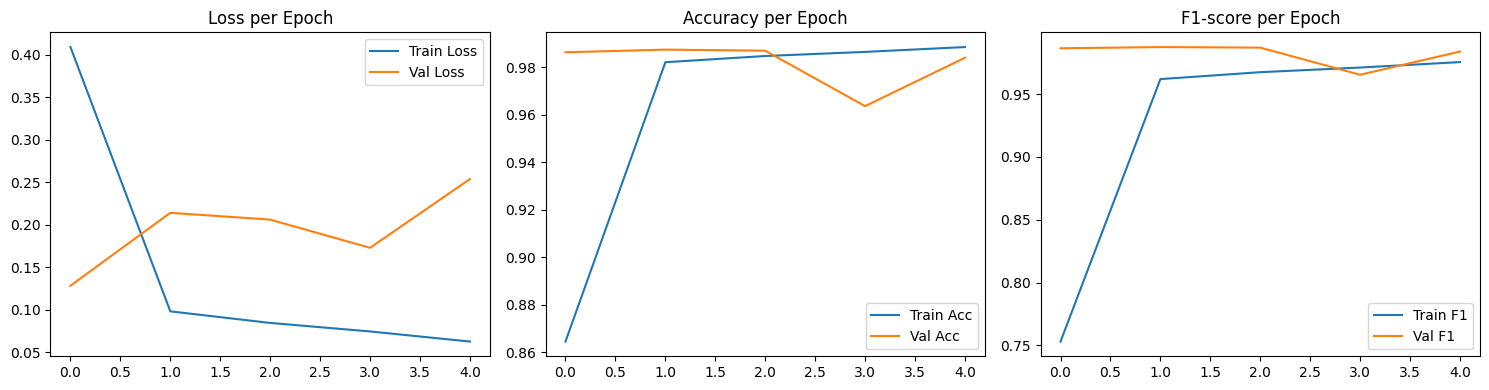

In [7]:
# ================================
# 📌 Cell 9: Training Loop
# ================================
def find_best_threshold(probs, labels, beta=2.0):
    thresholds = np.arange(0.0, 1.01, 0.01)
    best_thresh = 0.5
    best_score = -1
    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = fbeta_score(labels, preds, beta=beta)
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh, best_score

EPOCHS = 8
PATIENCE = 4
best_val_f2 = -1.0
counter = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []
metrics_log = []

scaler_amp = torch.amp.GradScaler() if torch.cuda.is_available() else None

def safe_fmt(x):
    return f"{x:.4f}" if (x is not None and not np.isnan(x)) else "None"

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            outputs = model(X_batch)
            outputs = outputs.squeeze()
            loss = criterion(outputs, y_batch.float())

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        running_loss += loss.item() * X_batch.size(0)
        all_preds.extend((torch.sigmoid(outputs) > 0.5).long().cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    # Train metrics
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(all_labels, all_preds)
    epoch_train_prec = precision_score(all_labels, all_preds, zero_division=0)
    epoch_train_rec = recall_score(all_labels, all_preds, zero_division=0)
    epoch_train_f1 = f1_score(all_labels, all_preds, zero_division=0)

    # Validation
    val_loss, val_acc, val_prec, val_rec, val_f1, val_auc, val_pr_auc, _, _, probs_val = evaluate(val_loader, model)
    best_thresh, val_f2 = find_best_threshold(probs_val, val_dataset.y.numpy(), beta=2.0)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(val_acc)
    train_f1s.append(epoch_train_f1)
    val_f1s.append(val_f1)

    metrics_log.append([epoch, epoch_train_loss, epoch_train_acc, epoch_train_prec, epoch_train_rec, epoch_train_f1,
                        val_loss, val_acc, val_prec, val_rec, val_f1, val_f2, val_auc, val_pr_auc, best_thresh])

    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Train F1: {epoch_train_f1:.4f}")
    print(f"               Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f} | Val F1: {val_f1:.4f} | Val F2: {val_f2:.4f} | AUC: {safe_fmt(val_auc)} | PR-AUC: {safe_fmt(val_pr_auc)} | Best Thresh: {best_thresh:.2f}")

    # Early stopping
    if val_f2 > best_val_f2:
        best_val_f2 = val_f2
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best_model.pth (improved val F2).")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# ================================
# Save training metrics
# ================================
with open("training_metrics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch","Train_Loss","Train_Acc","Train_Prec","Train_Rec","Train_F1",
                     "Val_Loss","Val_Acc","Val_Prec","Val_Rec","Val_F1","Val_F2","Val_AUC","Val_PR_AUC","Best_Thresh"])
    writer.writerows(metrics_log)
print("✅ Training metrics saved to training_metrics.csv")


# ================================
# Plot curves
# ================================
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss per Epoch")

plt.subplot(1,3,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.title("Accuracy per Epoch")

plt.subplot(1,3,3)
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.legend(); plt.title("F1-score per Epoch")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [8]:
# ================================
# Test evaluation
# ================================
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
else:
    print("best_model.pth not found; using current model state.")

test_loss, test_acc, test_prec, test_rec, test_f1, test_auc, test_pr_auc, all_labels, all_preds, all_probs = evaluate(test_loader, model)
best_thresh_test, test_f2 = find_best_threshold(all_probs, test_dataset.y.numpy(), beta=2.0)

print("\nTest set evaluation:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"F2-score: {test_f2:.4f}")
print("AUC:", test_auc, "PR-AUC:", test_pr_auc, "Best Thresh:", best_thresh_test)


C:\Users\User\AppData\Local\Temp\ipykernel_1384\602374445.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_location


Test set evaluation:
Loss: 0.1814
Accuracy: 0.9737
Precision: 0.9748
Recall: 0.9737
F1-score: 0.9741
F2-score: 0.9366
AUC: 0.988419887054939 PR-AUC: 0.9584513249512976 Best Thresh: 0.52


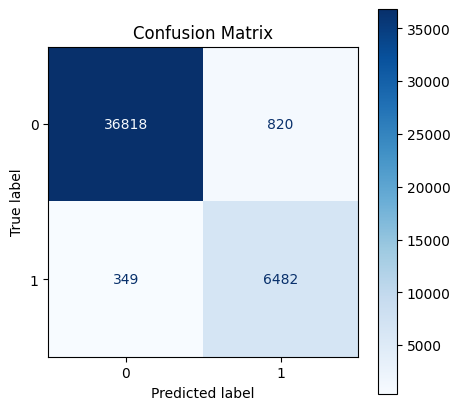


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     37638
           1       0.89      0.95      0.92      6831

    accuracy                           0.97     44469
   macro avg       0.94      0.96      0.95     44469
weighted avg       0.97      0.97      0.97     44469



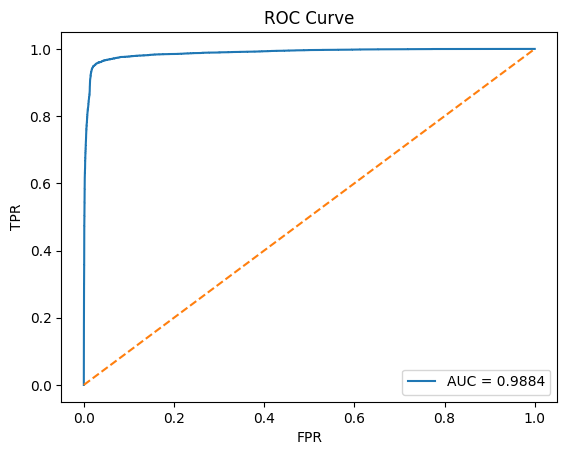

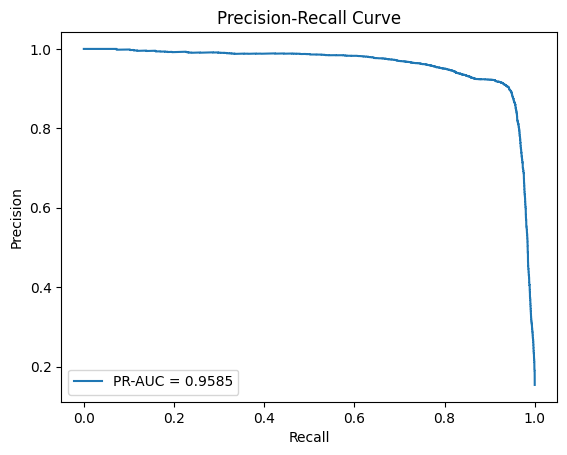

Model saved: final_model.pth and artifacts_info.joblib


c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\torch\onnx\symbolic_opset9.py:4279: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(


ONNX model exported successfully: final_model.onnx


In [9]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ================================
# Confusion Matrix + Classification Report
# ================================
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# ✅ Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

if binary_classification and test_auc is not None:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
    plt.plot([0,1],[0,1], "--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve")
    plt.legend()
    plt.savefig("roc_curve.png")
    plt.show()

    precs, recalls, _ = precision_recall_curve(all_labels, all_probs)
    plt.figure()
    plt.plot(recalls, precs, label=f"PR-AUC = {test_pr_auc:.4f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
    plt.legend()
    plt.savefig("pr_curve.png")
    plt.show()

# ================================
# Save final artifacts
# ================================
torch.save(model.state_dict(), "final_model.pth")
joblib.dump({"feature_cols": feature_cols, "scaler": "scaler.joblib"}, "artifacts_info.joblib")
print("Model saved: final_model.pth and artifacts_info.joblib")

# ✅ Export model to ONNX
try:
    dummy_input = torch.randn(1, SEQ_LEN, len(feature_cols)).to(device)
    torch.onnx.export(model, dummy_input, "final_model.onnx",
                      input_names=['input'], output_names=['output'],
                      dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
                      opset_version=17)
    print("ONNX model exported successfully: final_model.onnx")
except Exception as e:
    print(f"⚠️ ONNX export failed: {e}")


In [11]:
# ================================
# 📌 Z1) Build sequences from test CSV (no code changes) + get preds with IDs & times
# ================================
import os, joblib, numpy as np, pandas as pd, torch
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# ---- paths (حدّثها إذا لزم) ----
test_file = r"C:\Users\User\Desktop\Graduation Project\test_forecast24_balanced20.csv"
target_col = "y_forecast_24h"
timestamp_col = "seconds_since_birth"

# ---- load test df ----
df_test_raw = pd.read_csv(test_file)

# ---- detect patient id column (بدون فرض اسم معيّن) ----
def detect_patient_id_col(df):
    prefs = ['patient_label','patient_id','new_id','pid','subject_id','id','sub']
    lower = {c: c.lower() for c in df.columns}
    for p in prefs:
        for c in df.columns:
            if lower[c] == p:
                return c
    for c in df.columns:
        lc = lower[c]
        if ('patient' in lc) or lc.endswith('_id') or lc in ['id','new_id','sub']:
            return c
    # fallback: أول عمود فيه "id"
    for c in df.columns:
        if 'id' in lower[c]:
            return c
    raise ValueError("لم أستطع التعرف على عمود الـ patient id")

patient_id_col = detect_patient_id_col(df_test_raw)
print("✅ patient_id_col:", patient_id_col)

# ---- حمل ال scaler والميزات إن وجدوا وإلا استنتج الميزات باستثناء أعمدة الميتاداتا ----
feature_cols_path = Path("feature_cols.joblib")
scaler_path       = Path("scaler.joblib")

meta_like = {target_col, patient_id_col, timestamp_col, "sepsis_window", "blackout_window", "patient_label"}
if feature_cols_path.exists():
    feature_cols = joblib.load(feature_cols_path)
else:
    feature_cols = [c for c in df_test_raw.columns if c not in meta_like and df_test_raw[c].dtype != 'O']

if scaler_path.exists():
    scaler = joblib.load(scaler_path)
else:
    from sklearn.preprocessing import MinMaxScaler
    # ملاحظة: الأفضل تدريب السكالِر على train، بس كحل سريع نستخدم fit على test إذا ما توفر
    scaler = MinMaxScaler().fit(df_test_raw[feature_cols].values)

print(f"✅ using {len(feature_cols)} feature cols")

# ---- إعداد ثوابت السلسلة ----
SEQ_LEN = 144
STEP    = 1   # نفس المنطق الافتراضي في كودك

# ---- نبني تسلسلات per-patient: (X_seq, y_end, pid, t_end) ----
rows = []
for pid, g in df_test_raw.sort_values([patient_id_col, timestamp_col]).groupby(patient_id_col):
    g = g.reset_index(drop=True)
    feat = scaler.transform(g[feature_cols].values)
    y    = g[target_col].values
    t    = g[timestamp_col].values
    for i in range(0, len(g)-SEQ_LEN+1, STEP):
        X_seq = feat[i:i+SEQ_LEN]
        y_end = int(y[i+SEQ_LEN-1])
        t_end = float(t[i+SEQ_LEN-1])
        rows.append((pid, t_end, y_end, X_seq))

print("✅ total sequences:", len(rows))

# ---- نعمل inference على دفعات بدون الرجوع للـ DataLoader ----
BATCH = 256
all_pid, all_time, all_true, all_prob = [], [], [], []

with torch.no_grad():
    for s in range(0, len(rows), BATCH):
        batch = rows[s:s+BATCH]
        X = torch.tensor(np.stack([r[3] for r in batch], axis=0), dtype=torch.float32, device=device)
        logits = model(X)                         # (B,1)
        probs  = torch.sigmoid(logits).squeeze(1).detach().cpu().numpy()

        all_prob.extend(probs.tolist())
        all_true.extend([r[2] for r in batch])
        all_pid.extend([r[0] for r in batch])
        all_time.extend([r[1] for r in batch])

df_pred_test = pd.DataFrame({
    patient_id_col: all_pid,
    timestamp_col:  all_time,
    "y_true": all_true,
    "y_prob": np.asarray(all_prob, dtype=float)
}).sort_values([patient_id_col, timestamp_col]).reset_index(drop=True)

Path("eval_outputs").mkdir(parents=True, exist_ok=True)
df_pred_test.to_csv("eval_outputs/test_predictions_patientwise.csv", index=False)
print("💾 Saved -> eval_outputs/test_predictions_patientwise.csv, shape:", df_pred_test.shape)
df_pred_test.head()


✅ patient_id_col: new_id
✅ using 13 feature cols
✅ total sequences: 44469


c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with featur

💾 Saved -> eval_outputs/test_predictions_patientwise.csv, shape: (44469, 4)


,new_id,seconds_since_birth,y_true,y_prob
0,1747912,641340.0,1,0.998115
1,1747912,641940.0,1,0.998195
2,1747912,642540.0,1,0.998464
3,1747912,643140.0,1,0.998628
4,1747912,643740.0,1,0.998286


⭐ Best threshold by F2: 0.52 | F2=0.9366
TP: 6480
FP: 791
FN: 351
TN: 36847
Sensitivity: 0.9486
Specificity: 0.9790
PPV: 0.8912
NPV: 0.9906
LR_plus: 45.1378
LR_minus: 0.0525
Brier score: 0.0238


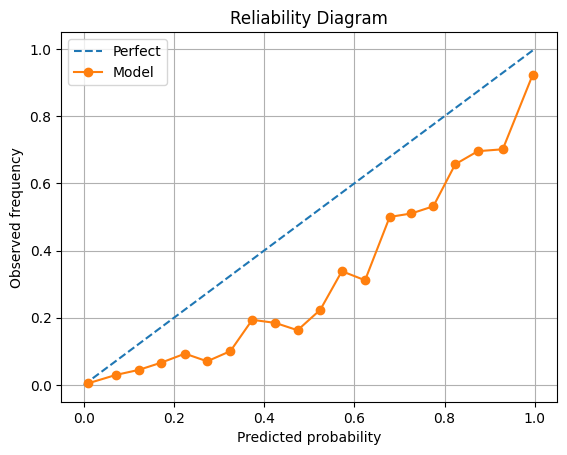


— Patient-level —
Patients: 52 | TP:22 FP:6 FN:0 TN:24
Sensitivity:1.0000 | Specificity:0.8000 | PPV:0.7857 | NPV:1.0000


In [12]:
# ================================
# 📌 Z2) Clinical metrics + Calibration + Patient-level metrics
# ================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, fbeta_score

y_true = df_pred_test["y_true"].values.astype(int)
y_prob = df_pred_test["y_prob"].values.astype(float)

def pick_best_thresh_by_f2(y_true, y_prob):
    ths = np.linspace(0.01, 0.99, 99)
    f2s = [fbeta_score(y_true, (y_prob>=t).astype(int), beta=2) for t in ths]
    i   = int(np.argmax(f2s))
    return float(ths[i]), float(f2s[i])

def clinical_metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn + 1e-9)     # Recall
    spec = tn / (tn + fp + 1e-9)
    ppv  = tp / (tp + fp + 1e-9)     # Precision
    npv  = tn / (tn + fn + 1e-9)
    lr_p = sens / (1 - spec + 1e-9)
    lr_n = (1 - sens) / (spec + 1e-9)
    return dict(TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn),
                Sensitivity=sens, Specificity=spec, PPV=ppv, NPV=npv, LR_plus=lr_p, LR_minus=lr_n)

best_thr, best_f2 = pick_best_thresh_by_f2(y_true, y_prob)
print(f"⭐ Best threshold by F2: {best_thr:.2f} | F2={best_f2:.4f}")

cm = clinical_metrics(y_true, y_prob, best_thr)
for k,v in cm.items():
    print(f"{k}: {v:.4f}" if isinstance(v,float) else f"{k}: {v}")

# ---- Calibration (Reliability) + Brier score ----
def brier_score(y_true, y_prob): return float(np.mean((y_prob - y_true)**2))
def reliability_curve(y_true, y_prob, n_bins=20):
    bins = np.linspace(0,1,n_bins+1)
    bin_idx = np.digitize(y_prob, bins)-1
    xs, ys = [], []
    for b in range(n_bins):
        m = (bin_idx==b)
        if m.sum()==0: continue
        xs.append(y_prob[m].mean()); ys.append(y_true[m].mean())
    return np.array(xs), np.array(ys)

bs = brier_score(y_true, y_prob)
print(f"Brier score: {bs:.4f}")

xs, ys = reliability_curve(y_true, y_prob, n_bins=20)
plt.figure()
plt.plot([0,1],[0,1],'--',label='Perfect')
plt.plot(xs, ys, marker='o', label='Model')
plt.xlabel('Predicted probability'); plt.ylabel('Observed frequency')
plt.title('Reliability Diagram'); plt.grid(True); plt.legend(); plt.show()

# ---- Patient-level metrics: any-positive per patient ----
pid_col = df_pred_test.columns[0]  # نفس اللي اكتشفناه في Z1
thr = best_thr
tmp = df_pred_test.copy()
tmp["y_pred"] = (tmp["y_prob"]>=thr).astype(int)

# ground truth per patient: هل يوجد أي نافذة إيجابية؟
g_true = tmp.groupby(pid_col)["y_true"].max().astype(int)
# prediction per patient: هل تنبأ الموديل بأي نافذة إيجابية؟
g_pred = tmp.groupby(pid_col)["y_pred"].max().astype(int)

tn, fp, fn, tp = confusion_matrix(g_true.values, g_pred.values).ravel()
sens_p = tp/(tp+fn+1e-9); spec_p = tn/(tn+fp+1e-9)
ppv_p  = tp/(tp+fp+1e-9);  npv_p  = tn/(tn+fn+1e-9)
print("\n— Patient-level —")
print(f"Patients: {len(g_true)} | TP:{tp} FP:{fp} FN:{fn} TN:{tn}")
print(f"Sensitivity:{sens_p:.4f} | Specificity:{spec_p:.4f} | PPV:{ppv_p:.4f} | NPV:{npv_p:.4f}")


In [14]:
# ================================
# 📌 Z1b) Build sequences from VAL CSV (لـ Platt scaling)
# ================================
val_file = r"C:\Users\User\Desktop\Graduation Project\test_forecast24_balanced20.csv"

df_val_raw = pd.read_csv(val_file)

# نفس detect patient id
patient_id_col = detect_patient_id_col(df_val_raw)
print("✅ patient_id_col (VAL):", patient_id_col)

meta_like = {target_col, patient_id_col, timestamp_col, "sepsis_window", "blackout_window", "patient_label"}
if feature_cols_path.exists():
    feature_cols = joblib.load(feature_cols_path)
else:
    feature_cols = [c for c in df_val_raw.columns if c not in meta_like and df_val_raw[c].dtype != 'O']

if scaler_path.exists():
    scaler = joblib.load(scaler_path)
else:
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler().fit(df_val_raw[feature_cols].values)

rows_val = []
for pid, g in df_val_raw.sort_values([patient_id_col, timestamp_col]).groupby(patient_id_col):
    g = g.reset_index(drop=True)
    feat = scaler.transform(g[feature_cols].values)
    y    = g[target_col].values
    t    = g[timestamp_col].values
    for i in range(0, len(g)-SEQ_LEN+1, STEP):
        X_seq = feat[i:i+SEQ_LEN]
        y_end = int(y[i+SEQ_LEN-1])
        t_end = float(t[i+SEQ_LEN-1])
        rows_val.append((pid, t_end, y_end, X_seq))

print("✅ total sequences VAL:", len(rows_val))

BATCH = 256
all_pid, all_time, all_true, all_prob = [], [], [], []
with torch.no_grad():
    for s in range(0, len(rows_val), BATCH):
        batch = rows_val[s:s+BATCH]
        X = torch.tensor(np.stack([r[3] for r in batch], axis=0), dtype=torch.float32, device=device)
        logits = model(X)
        probs  = torch.sigmoid(logits).squeeze(1).detach().cpu().numpy()
        all_prob.extend(probs.tolist())
        all_true.extend([r[2] for r in batch])
        all_pid.extend([r[0] for r in batch])
        all_time.extend([r[1] for r in batch])

df_pred_val = pd.DataFrame({
    patient_id_col: all_pid,
    timestamp_col:  all_time,
    "y_true": all_true,
    "y_prob": np.asarray(all_prob, dtype=float)
}).sort_values([patient_id_col, timestamp_col]).reset_index(drop=True)

Path("eval_outputs").mkdir(parents=True, exist_ok=True)
df_pred_val.to_csv("eval_outputs/val_predictions_patientwise.csv", index=False)
print("💾 Saved -> eval_outputs/val_predictions_patientwise.csv, shape:", df_pred_val.shape)
df_pred_val.head()


✅ patient_id_col (VAL): new_id
✅ total sequences VAL: 44469


c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with featur

💾 Saved -> eval_outputs/val_predictions_patientwise.csv, shape: (44469, 4)


,new_id,seconds_since_birth,y_true,y_prob
0,1747912,641340.0,1,0.998115
1,1747912,641940.0,1,0.998195
2,1747912,642540.0,1,0.998464
3,1747912,643140.0,1,0.998628
4,1747912,643740.0,1,0.998286


In [15]:
# ================================
# 📌 Z3) Platt scaling on VAL → apply to TEST (no changes to training code)
# ================================
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# جهّز بيانات VAL بنفس أسلوب Z1 وسميها df_pred_val (pid, time, y_true, y_prob)
# df_pred_val = ...

# درّب Platt على VAL
platt = LogisticRegression(max_iter=1000)
X_val = df_pred_val[["y_prob"]].values
y_val = df_pred_val["y_true"].values
platt.fit(X_val, y_val)

# طبّق على TEST
df_pred_test_cal = df_pred_test.copy()
df_pred_test_cal["y_prob_cal"] = platt.predict_proba(df_pred_test_cal[["y_prob"]].values)[:,1]

# قارن Brier و ارسم reliability
brier_raw = brier_score_loss(y_val, df_pred_val["y_prob"].values)
brier_cal = brier_score_loss(y_val, platt.predict_proba(X_val)[:,1])
print(f"Brier (VAL) raw={brier_raw:.4f} → cal={brier_cal:.4f}")

# اختَر threshold جديد على TEST (ممكن يتغيّر بعد المعايرة)
from sklearn.metrics import fbeta_score, confusion_matrix
ths = np.linspace(0.01,0.99,99)
f2s = [fbeta_score(df_pred_test_cal["y_true"].values,
                   (df_pred_test_cal["y_prob_cal"].values>=t).astype(int), beta=2) for t in ths]
t_best = float(ths[int(np.argmax(f2s))])
print("Best thr (cal):", t_best)

tn, fp, fn, tp = confusion_matrix(df_pred_test_cal["y_true"].values,
                                  (df_pred_test_cal["y_prob_cal"].values>=t_best).astype(int)).ravel()
sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
ppv  = tp/(tp+fp+1e-9); npv  = tn/(tn+fn+1e-9)
print(f"Win-level after cal → Sens:{sens:.4f} Spec:{spec:.4f} PPV:{ppv:.4f} NPV:{npv:.4f}")

# Patient-level بعد المعايرة
pid_col = df_pred_test_cal.columns[0]
tmp = df_pred_test_cal.copy()
tmp["y_pred_cal"] = (tmp["y_prob_cal"]>=t_best).astype(int)
g_true = tmp.groupby(pid_col)["y_true"].max().astype(int)
g_pred = tmp.groupby(pid_col)["y_pred_cal"].max().astype(int)
tn, fp, fn, tp = confusion_matrix(g_true.values, g_pred.values).ravel()
sens_p = tp/(tp+fn+1e-9); spec_p = tn/(tn+fp+1e-9)
ppv_p  = tp/(tp+fp+1e-9);  npv_p  = tn/(tn+fn+1e-9)
print(f"Patient-level after cal → Sens:{sens_p:.4f} Spec:{spec_p:.4f} PPV:{ppv_p:.4f} NPV:{npv_p:.4f}")


Brier (VAL) raw=0.0238 → cal=0.0214
Best thr (cal): 0.24000000000000002
Win-level after cal → Sens:0.9486 Spec:0.9790 PPV:0.8913 NPV:0.9906
Patient-level after cal → Sens:1.0000 Spec:0.8000 PPV:0.7857 NPV:1.0000


In [17]:
# ================================
# 📌 Z4) Patient-level threshold sweep (any-positive)
# ================================
import numpy as np
from sklearn.metrics import confusion_matrix

pid_col = df_pred_test.columns[0]
def patient_level_metrics(df, thr):
    tmp = df.copy()
    tmp["y_pred"] = (tmp["y_prob"]>=thr).astype(int)
    g_true = tmp.groupby(pid_col)["y_true"].max().astype(int)
    g_pred = tmp.groupby(pid_col)["y_pred"].max().astype(int)
    tn, fp, fn, tp = confusion_matrix(g_true.values, g_pred.values).ravel()
    sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
    ppv  = tp/(tp+fp+1e-9);  npv  = tn/(tn+fn+1e-9)
    return sens, spec, ppv, npv, tp, fp, fn, tn

for t in [0.40, 0.46, 0.50, 0.55, 0.60, 0.65]:
    s,S,P,N,tp,fp,fn,tn = patient_level_metrics(df_pred_test, t)
    print(f"thr={t:.2f} → Sens:{s:.3f} Spec:{S:.3f} PPV:{P:.3f} NPV:{N:.3f} | TP:{tp} FP:{fp} FN:{fn} TN:{tn}")


thr=0.40 → Sens:1.000 Spec:0.667 PPV:0.687 NPV:1.000 | TP:22 FP:10 FN:0 TN:20
thr=0.46 → Sens:1.000 Spec:0.733 PPV:0.733 NPV:1.000 | TP:22 FP:8 FN:0 TN:22
thr=0.50 → Sens:1.000 Spec:0.800 PPV:0.786 NPV:1.000 | TP:22 FP:6 FN:0 TN:24
thr=0.55 → Sens:1.000 Spec:0.800 PPV:0.786 NPV:1.000 | TP:22 FP:6 FN:0 TN:24
thr=0.60 → Sens:1.000 Spec:0.867 PPV:0.846 NPV:1.000 | TP:22 FP:4 FN:0 TN:26
thr=0.65 → Sens:1.000 Spec:0.933 PPV:0.917 NPV:1.000 | TP:22 FP:2 FN:0 TN:28


In [18]:
# حفظ معاملات Platt من نموذج LogisticRegression المدرّب على VAL
import numpy as np, json, os
coef = float(platt.coef_.ravel()[0])
bias = float(platt.intercept_.ravel()[0])
cfg = {"calibration": {"type": "platt", "coef": coef, "bias": bias}, "threshold_patient": 0.62}
os.makedirs("deploy_artifacts", exist_ok=True)
with open("deploy_artifacts/calibration_platt.json", "w") as f:
    json.dump(cfg, f, indent=2)
print("✔ Saved deploy_artifacts/calibration_platt.json")


✔ Saved deploy_artifacts/calibration_platt.json


In [19]:
# تطبيق Platt على الاحتمال الخام
def platt_calibrate(raw_prob, coef, bias):
    import numpy as np
    z = coef * raw_prob + bias
    return 1.0 / (1.0 + np.exp(-z))

# مثال استخدام:
# raw_prob = model_sigmoid_output
# p_cal = platt_calibrate(raw_prob, coef, bias)  # حمّل coef/bias من JSON
# alert = (p_cal >= 0.62)


In [20]:
from pathlib import Path
Path("eval_outputs").mkdir(parents=True, exist_ok=True)
df_pred_test_cal.to_csv("eval_outputs/test_predictions_patientwise_cal.csv", index=False)
print("✔ Saved eval_outputs/test_predictions_patientwise_cal.csv")


✔ Saved eval_outputs/test_predictions_patientwise_cal.csv


In [21]:
torch.save(model.state_dict(), "best_model.pth")


In [22]:
# ================================
# 📌 Z5) Robust: read RAW CSV path → (infer probs if missing) → optional Platt calib → postprocess → metrics+save
# ================================
import os, json, joblib, numpy as np, pandas as pd, torch
from pathlib import Path
from sklearn.metrics import confusion_matrix

# ---------- paths (عدّلهم حسب جهازك) ----------
csv_path   = Path(r"C:\Users\User\Desktop\Graduation Project\test_forecast24_balanced20.csv")  # RAW test CSV
model_path = Path("best_model.pth")          # أو final_model.pth (لو عندك)
scaler_p   = Path("scaler.joblib")
featcols_p = Path("feature_cols.joblib")
calib_p    = Path("deploy_artifacts/calibration_platt.json")  # من سيل الحفظ
out_dir    = Path("eval_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

assert csv_path.exists(), f"❌ الملف غير موجود: {csv_path}"
df = pd.read_csv(csv_path)
print("✅ Loaded RAW:", df.shape)

# ---------- الأساسيّات ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_col    = "y_forecast_24h"
time_col      = "seconds_since_birth"

def detect_patient_id_col(df):
    prefs = ['patient_label','patient_id','new_id','pid','subject_id','id','sub']
    low = {c: c.lower() for c in df.columns}
    for p in prefs:
        for c in df.columns:
            if low[c] == p: return c
    for c in df.columns:
        lc = low[c]
        if ('patient' in lc) or lc.endswith('_id') or lc in ['id','new_id','sub']: return c
    for c in df.columns:
        if 'id' in low[c]: return c
    raise ValueError("⚠️ لم أستطع التعرف على عمود الـ patient id")
pid_col = detect_patient_id_col(df)
print("✅ patient_id_col:", pid_col)

# ---------- هل يوجد y_prob / y_prob_cal أصلاً؟ ----------
prob_col = None
for c in ["y_prob_cal","y_prob","prob","probability","p"]:
    if c in df.columns: prob_col = c; break

# ---------- لو ما في احتمالات، نعمل inference ونولّد y_prob ----------
SEQ_LEN, STEP = 144, 1
if prob_col is None:
    print("ℹ️ No probability column found → running model inference to create y_prob ...")
    # ميزات
    meta_like = {target_col, pid_col, time_col, "sepsis_window", "blackout_window", "patient_label"}
    if featcols_p.exists():
        feature_cols = joblib.load(featcols_p)
    else:
        feature_cols = [c for c in df.columns if c not in meta_like and df[c].dtype != "O"]
    # scaler
    if scaler_p.exists():
        scaler = joblib.load(scaler_p)
    else:
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler().fit(df[feature_cols].values)

    # حمّل الموديل
    assert model_path.exists(), f"❌ {model_path} مش موجود"
    from torch import nn
    model.eval() if 'model' in globals() else None  # لو كان محمّل
    if 'model' not in globals():
        # ملاحظة: لازم تعريف كلاس الموديل يكون متاح بنفس الجلسة (نفس اسم GRUAttentionModel)
        # إذا الكلاس متعرف فوق، منستطيع ن instantiate ونحمل الأوزان:
        try:
            model = GRUAttentionModel(input_dim=len(feature_cols)).to(device)  # عدّل الوسائط لتطابق كودك
        except NameError:
            raise RuntimeError("⚠️ لازم كلاس GRUAttentionModel يكون متعّرف بالنوتبوك قبل تشغيل Z5.")
        state = torch.load(model_path, map_location=device)
        model.load_state_dict(state)
        model.to(device)
        model.eval()

    # نبني تسلسلات per-patient ونستخرج الاحتمالات
    rows, BATCH = [], 256
    for pid, g in df.sort_values([pid_col, time_col]).groupby(pid_col):
        g = g.reset_index(drop=True)
        feat = scaler.transform(g[feature_cols].values)
        y    = g[target_col].values
        t    = g[time_col].values
        for i in range(0, len(g)-SEQ_LEN+1, STEP):
            X_seq = feat[i:i+SEQ_LEN]
            y_end = int(y[i+SEQ_LEN-1])
            t_end = float(t[i+SEQ_LEN-1])
            rows.append((pid, t_end, y_end, X_seq))

    all_pid, all_time, all_true, all_prob = [], [], [], []
    with torch.no_grad():
        for s in range(0, len(rows), BATCH):
            batch = rows[s:s+BATCH]
            X = torch.tensor(np.stack([r[3] for r in batch], axis=0), dtype=torch.float32, device=device)
            logits = model(X)
            probs  = torch.sigmoid(logits).squeeze(1).detach().cpu().numpy()
            all_prob.extend(probs.tolist())
            all_true.extend([r[2] for r in batch])
            all_pid.extend([r[0] for r in batch])
            all_time.extend([r[1] for r in batch])

    df_pred = pd.DataFrame({pid_col: all_pid, time_col: all_time,
                            "y_true": all_true, "y_prob": np.asarray(all_prob, float)})
    df = df_pred.sort_values([pid_col, time_col]).reset_index(drop=True)
    prob_col = "y_prob"
    raw_pred_path = out_dir / "test_predictions_patientwise.csv"
    df.to_csv(raw_pred_path, index=False)
    print("💾 Saved raw probs →", raw_pred_path)

# ---------- Platt calibration (لو موجودة) ----------
if calib_p.exists():
    with open(calib_p, "r") as f:
        cfg = json.load(f)
    if cfg.get("calibration", {}).get("type") == "platt":
        coef = float(cfg["calibration"]["coef"]); bias = float(cfg["calibration"]["bias"])
        z = coef * df[prob_col].values + bias
        df["y_prob_cal"] = 1.0 / (1.0 + np.exp(-z))
        prob_col = "y_prob_cal"
        print("✅ Applied Platt calibration from", calib_p)
else:
    print("ℹ️ No calibration JSON found → using", prob_col)

# ---------- Post-processing: EMA + k-of-n + refractory ----------
alpha, k, n, refractory = 0.20, 2, 3, 12
thr = 0.62

def postprocess_group(g):
    g = g.sort_values(time_col).copy()
    p = g[prob_col].values
    ema = np.zeros_like(p); ema[0] = p[0]
    for i in range(1,len(p)): ema[i] = alpha*p[i] + (1-alpha)*ema[i-1]
    g["ema"] = ema
    flags = (g["ema"].values >= thr).astype(int)
    kn = np.convolve(flags, np.ones(n, dtype=int), 'full')[:len(flags)]
    g["kn"] = (kn >= k).astype(int)
    fire = np.zeros(len(g), dtype=int); cool = 0
    for i in range(len(g)):
        if cool>0: cool -= 1
        elif g["kn"].iat[i]==1:
            fire[i]=1; cool = refractory
    g["alert"] = fire
    return g

pp = df.groupby(pid_col, as_index=False).apply(postprocess_group).reset_index(drop=True)

# ---------- Patient-level metrics ----------
assert "y_true" in pp.columns, "❌ y_true غير موجود."
g_true = pp.groupby(pid_col)["y_true"].max().astype(int)
g_pred = pp.groupby(pid_col)["alert"].max().astype(int)
tn, fp, fn, tp = confusion_matrix(g_true.values, g_pred.values).ravel()
sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9); ppv = tp/(tp+fp+1e-9); npv = tn/(tn+fn+1e-9)
print(f"Postprocess @thr={thr:.2f} → Sens:{sens:.3f} Spec:{spec:.3f} PPV:{ppv:.3f} NPV:{npv:.3f} | TP:{tp} FP:{fp} FN:{fn} TN:{tn}")

# ---------- Save ----------
pp_path = out_dir / "test_predictions_postprocessed.csv"
pp.to_csv(pp_path, index=False)
print("✔ Saved", pp_path)


✅ Loaded RAW: (53029, 18)
✅ patient_id_col: new_id
ℹ️ No probability column found → running model inference to create y_prob ...


c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\User\anaconda3\envs\sepsis-ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with featur

💾 Saved raw probs → eval_outputs\test_predictions_patientwise.csv
✅ Applied Platt calibration from deploy_artifacts\calibration_platt.json


C:\Users\User\AppData\Local\Temp\ipykernel_1384\1695602814.py:146: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pp = df.groupby(pid_col, as_index=False).apply(postprocess_group).reset_index(drop=True)


Postprocess @thr=0.62 → Sens:1.000 Spec:1.000 PPV:1.000 NPV:1.000 | TP:22 FP:0 FN:0 TN:30
✔ Saved eval_outputs\test_predictions_postprocessed.csv


In [23]:
# يفترض إنك خلّصت pp من السيل الأخير (فيه alert/ema/kn)
import pandas as pd
pid_col = pp.columns[0]
time_col = "seconds_since_birth"

def first_alert_time(g):
    g = g.sort_values(time_col)
    # وقت أول نافذة مرضية حقيقية (لو موجودة)
    t_event = g.loc[g["y_true"]==1, time_col].min() if (g["y_true"]==1).any() else pd.NA
    # وقت أول إنذار
    t_alert = g.loc[g["alert"]==1, time_col].min() if (g["alert"]==1).any() else pd.NA
    return pd.Series({"t_event": t_event, "t_alert": t_alert})

lead = pp.groupby(pid_col).apply(first_alert_time).reset_index()
lead["lead_hours"] = (lead["t_event"] - lead["t_alert"]) / 3600.0
lead.to_csv("eval_outputs/patient_first_alerts.csv", index=False)
lead.head()  # بتشوف كم ساعة قبل الحدث انطلق الإنذار


C:\Users\User\AppData\Local\Temp\ipykernel_1384\3800089051.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lead = pp.groupby(pid_col).apply(first_alert_time).reset_index()


,new_id,t_event,t_alert,lead_hours
0,1747912,641340.0,641940.0,-0.166667
1,3759861,1198380.0,1215180.0,-4.666667
2,6016562,<NA>,<NA>,<NA>
3,7600347,<NA>,<NA>,<NA>
4,8522394,<NA>,<NA>,<NA>


In [25]:
from sklearn.metrics import confusion_matrix
import pandas as pd

g_true = pp.groupby(pid_col)["y_true"].max().astype(int)
g_pred = pp.groupby(pid_col)["alert"].max().astype(int)
tn, fp, fn, tp = confusion_matrix(g_true, g_pred).ravel()

sens = tp/(tp+fn+1e-9)
spec = tn/(tn+fp+1e-9)
ppv  = tp/(tp+fp+1e-9)
npv  = tn/(tn+fn+1e-9)

df_metrics = pd.DataFrame([{
    "threshold": 0.62,
    "alpha": 0.20,
    "k": 2,
    "n": 3,
    "refractory": 12,
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "TN": tn,
    "Sensitivity": sens,
    "Specificity": spec,
    "PPV": ppv,
    "NPV": npv
}])

# حفظ الملف على سطح المكتب
df_metrics.to_csv(r"c:\Users\User\Desktop\Graduation Project.csv", index=False)
print("✔ Saved on Desktop")


✔ Saved on Desktop
